# Import Libaries

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [5]:

states = ['A', 'B', 'C']
actions = ['left', 'right']

rewards = {
    'A': 1,
    'B': 2,
    'C': 3
}

transition_prob = {
    'A': {'left': ('A', 0.7), 'right': ('B', 0.3)},
    'B': {'left': ('A', 0.4), 'right': ('C', 0.6)},
    'C': {'left': ('B', 0.5), 'right': ('C', 0.5)}
}

gamma = 0.9 
theta = 0.01  

V = {s: 0 for s in states}

def value_iteration():
    while True:
        delta = 0
        for s in states:
            v = V[s]
            values = []
            
            for a in actions:
                next_state, prob = transition_prob[s][a]
                value = prob * (rewards[next_state] + gamma * V[next_state])
                values.append(value)
            
            V[s] = max(values)
            delta = max(delta, abs(v - V[s]))
        
        if delta < theta:
            break

value_iteration()

print("Optimal Value Function:")
for s in states:
    print(f"State {s}: {V[s]:.2f}")

Optimal Value Function:
State A: 1.88
State B: 3.27
State C: 2.73


In [7]:
policy = {}

for s in states:
    action_values = {}
    
    for a in actions:
        next_state, prob = transition_prob[s][a]
        action_values[a] = prob * (rewards[next_state] + gamma * V[next_state])
    
    policy[s] = max(action_values, key=action_values.get)

print("\nOptimal Policy:")
for s in policy:
    print(f"State {s} -> {policy[s]}")


Optimal Policy:
State A -> left
State B -> right
State C -> right


In [11]:

data = [
    ('Sunny', 'No'),
    ('Sunny', 'No'),
    ('Overcast', 'Yes'),
    ('Rain', 'Yes'),
    ('Rain', 'Yes'),
    ('Rain', 'No'),
    ('Overcast', 'Yes'),
    ('Sunny', 'No'),
    ('Sunny', 'Yes'),
    ('Rain', 'Yes')
]

classes = ['Yes', 'No']
feature_values = ['Sunny', 'Overcast', 'Rain']

prior = {}
for c in classes:
    prior[c] = sum(1 for d in data if d[1] == c) / len(data)

print("Prior Probabilities:", prior)

likelihood = {}
for val in feature_values:
    likelihood[val] = {}
    for c in classes:
        count = sum(1 for d in data if d[0] == val and d[1] == c)
        total = sum(1 for d in data if d[1] == c)
        likelihood[val][c] = count / total

print("\nLikelihood:")
print(likelihood)

Prior Probabilities: {'Yes': 0.6, 'No': 0.4}

Likelihood:
{'Sunny': {'Yes': 0.16666666666666666, 'No': 0.75}, 'Overcast': {'Yes': 0.3333333333333333, 'No': 0.0}, 'Rain': {'Yes': 0.5, 'No': 0.25}}


In [13]:
def predict(feature):
    posterior = {}
    
    for c in classes:
        posterior[c] = prior[c] * likelihood[feature][c]
    
    return max(posterior, key=posterior.get)

# Test prediction
test_feature = 'Sunny'
result = predict(test_feature)

print(f"\nPrediction for '{test_feature}': {result}")


Prediction for 'Sunny': No


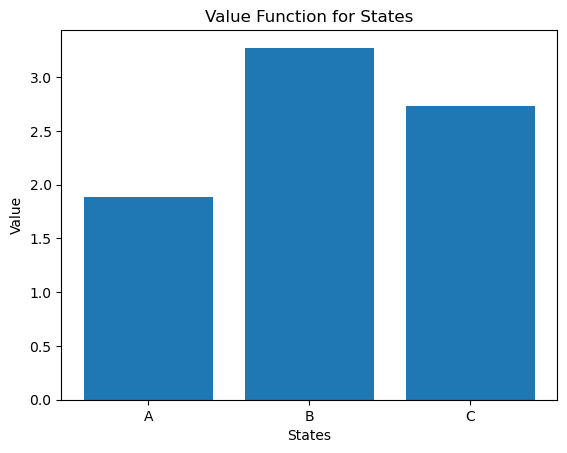

In [15]:
# Plot Value Function
states_list = list(V.keys())
values_list = list(V.values())

plt.bar(states_list, values_list)
plt.title("Value Function for States")
plt.xlabel("States")
plt.ylabel("Value")
plt.show()